In [1]:
import pandas as pd
import json
import random
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms

from tqdm import tqdm
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import os

!pip install -q kaggle

!kaggle datasets download -d apollo2506/eurosat-dataset

!unzip -q eurosat-dataset.zip -d data/

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [01:41<00:00, 21.5MB/s]



In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
DATA_DIR = "/content/data/EuroSAT"

train_df = pd.read_csv(f"{DATA_DIR}/train.csv").drop(columns=["Unnamed: 0"])
val_df   = pd.read_csv(f"{DATA_DIR}/validation.csv").drop(columns=["Unnamed: 0"])
test_df  = pd.read_csv(f"{DATA_DIR}/test.csv").drop(columns=["Unnamed: 0"])

with open(f"{DATA_DIR}/label_map.json") as f:
    label_map = json.load(f)

print(train_df.shape, val_df.shape, test_df.shape)
print(label_map)

(18900, 3) (5400, 3) (2700, 3)
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


The same dataset and its split will be used for ResNet training as for Baseline CNN.

In [6]:
class EuroSATDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = f"{self.data_dir}/{row['Filename']}"
        image = Image.open(img_path).convert("RGB")
        label = row['Label']

        if self.transform:
            image = self.transform(image)

        return image, label

Transformations applied to the dataset are the same as for Baseline CNN, including normalization, random rotation, vertical and horizontal flips.

Mean and standard deviation used for normalization will be different. Imagenet ones will be applied, as the model has already been trained on them, so the model is more likely to produce better results.

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [8]:
train_dataset = EuroSATDataset(train_df, DATA_DIR, transform = train_transform)
val_dataset = EuroSATDataset(val_df, DATA_DIR, transform = eval_transform)
test_dataset = EuroSATDataset(test_df, DATA_DIR, transform = eval_transform)

In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

ResNet with Imagenet weights will be called and then fine-tuned to be able to classify EuroSAT dataset.

In [10]:
resnet = models.resnet18(weights='IMAGENET1K_V1')

for param in resnet.parameters():
    param.requires_grad = False

num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 10)

resnet = resnet.to(device)
print(resnet.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s]


Linear(in_features=512, out_features=10, bias=True)


For fine-tuning purposes the pretrained backbone is frozen and only the newly added classification head is trained. This allows the classifier to adapt to the target dataset without changing the pretrained layers.

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    resnet.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

`CrossEntropyLoss` is used as the loss function since the task is multi-class image classification.

`AdamW` is used as an optimizer with the same standard learning rate and weight decay, as the baseline CNN, as it has proven to be a decent choice.

`ReduceLROnPlateau` is also used in order to make the training more effective by automatically decreasing learning rate when the model's performance stops improving.

Training and validation loops will be established next.

In [12]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

Training and validation run in separate loops using `model.train()`/`model.eval()` to disable Dropout and BatchNorm during validation. Both loss and accuracy are tracked per epoch to monitor optimization progress.

Early stopping is also used. It is based on validation accuracy with `patience=4`. The best-performing checkpoint (by validation accuracy) is saved rather than simply using the final epoch's weights.

In [13]:
patience = 4
best_val_acc = 0.0
epochs_no_improvement = 0

num_epochs = 50

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(resnet, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(resnet, val_loader, criterion, device)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improvement = 0
        torch.save(resnet.state_dict(), "best_resnet.pth")
    else:
        epochs_no_improvement += 1

    if epochs_no_improvement >= patience:
        print(f"Early stopping triggered after epoch {epoch+1}")
        break

100%|██████████| 169/169 [00:05<00:00, 32.93it/s]


Epoch 1/50 | Train Loss: 0.9545 Acc: 0.6954 | Val Loss: 0.7394 Acc: 0.7709


100%|██████████| 169/169 [00:05<00:00, 32.86it/s]


Epoch 2/50 | Train Loss: 0.7141 Acc: 0.7669 | Val Loss: 0.6757 Acc: 0.7919


100%|██████████| 169/169 [00:05<00:00, 32.61it/s]


...

Epoch 8/50 | Train Loss: 0.6575 Acc: 0.7832 | Val Loss: 0.6203 Acc: 0.8081


100%|██████████| 169/169 [00:04<00:00, 35.14it/s]


Epoch 9/50 | Train Loss: 0.6496 Acc: 0.7850 | Val Loss: 0.6179 Acc: 0.8106


100%|██████████| 169/169 [00:04<00:00, 34.07it/s]

Epoch 10/50 | Train Loss: 0.6199 Acc: 0.7942 | Val Loss: 0.6203 Acc: 0.8056
Early stopping triggered after epoch 10


The training process stopped after 10th epoch, which means that the model established after the 6th epoch was determined to be the best one. Its performance was as follows:

|Train Loss| Train Accuracy| Validation Loss| Validation Accuracy|
| :---: | :---: | :---: | :---: |
|0.6611|0.7800|0.6028|0.8113|

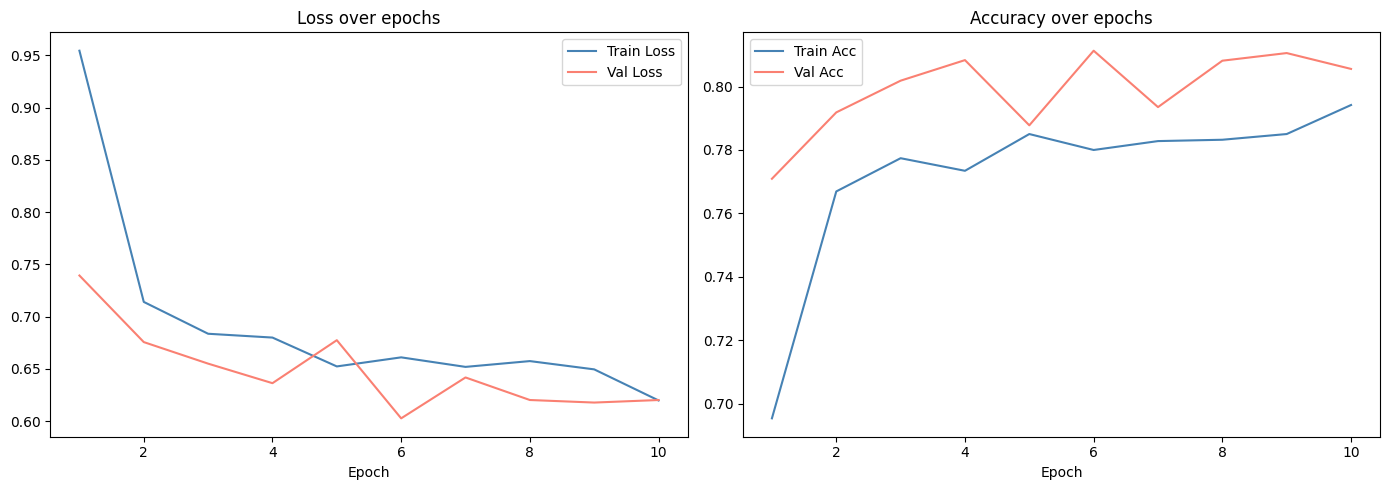

In [14]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
axes[0].plot(epochs, history["val_loss"], label="Val Loss", color="salmon")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="Train Acc", color="steelblue")
axes[1].plot(epochs, history["val_acc"], label="Val Acc", color="salmon")
axes[1].set_title("Accuracy over epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

As expected, the model wasn't very effective at classification of images from EuroSAT dataset, as it was trained on different data and, therefore, couldn't utilize learned patterns to full extent.

Overall, the Baseline CNN managed to outperform ResNet model by all metrics.

It was decided to unfreeze the last layer of the best model to improve its performance by training it on the EuroSAT dataset.

In [15]:
resnet.load_state_dict(torch.load("best_resnet.pth"))

for name, param in resnet.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

The same optimizer has been used with learning rate decreased to 1e-4, as it is considered to be more effective for fine-tuning. The scheduler remained the same.

In [16]:
num_epochs = 50
patience = 4
best_val_acc = 0.0
epochs_no_improvement = 0

history_finetune = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(resnet, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(resnet, val_loader, criterion, device)

    scheduler.step(val_loss)

    history_finetune["train_loss"].append(train_loss)
    history_finetune["train_acc"].append(train_acc)
    history_finetune["val_loss"].append(val_loss)
    history_finetune["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improvement = 0
        torch.save(resnet.state_dict(), "best_resnet_finetuned.pth")
    else:
        epochs_no_improvement += 1 >= patience:
        print(f"Early stopping triggered after epoch {epoch+1}")
        break

100%|██████████| 169/169 [00:05<00:00, 31.85it/s]


Epoch 1/50 | Train Loss: 0.4999 Acc: 0.8353 | Val Loss: 0.3355 Acc: 0.8881


100%|██████████| 169/169 [00:04<00:00, 34.56it/s]


Epoch 2/50 | Train Loss: 0.3444 Acc: 0.8828 | Val Loss: 0.2673 Acc: 0.9107


100%|██████████| 169/169 [00:05<00:00, 32.11it/s]


...

Epoch 23/50 | Train Loss: 0.0779 Acc: 0.9731 | Val Loss: 0.1317 Acc: 0.9550


100%|██████████| 169/169 [00:05<00:00, 33.34it/s]


Epoch 24/50 | Train Loss: 0.0776 Acc: 0.9733 | Val Loss: 0.1342 Acc: 0.9530


100%|██████████| 169/169 [00:05<00:00, 33.44it/s]

Epoch 25/50 | Train Loss: 0.0761 Acc: 0.9730 | Val Loss: 0.1314 Acc: 0.9548
Early stopping triggered after epoch 25


Early stopping was triggered after 25th epoch. The best model achieved at epoch 21 had the following results:

|Train Loss| Train Accuracy| Validation Loss| Validation Accuracy|
| :---: | :---: | :---: | :---: |
|0.0886|0.9698|0.1306|0.9552|

The results indicate a huge improvement compared to the previous version, which means that the unfreezing of one of the linear layers of the ResNet model brought succesful results.

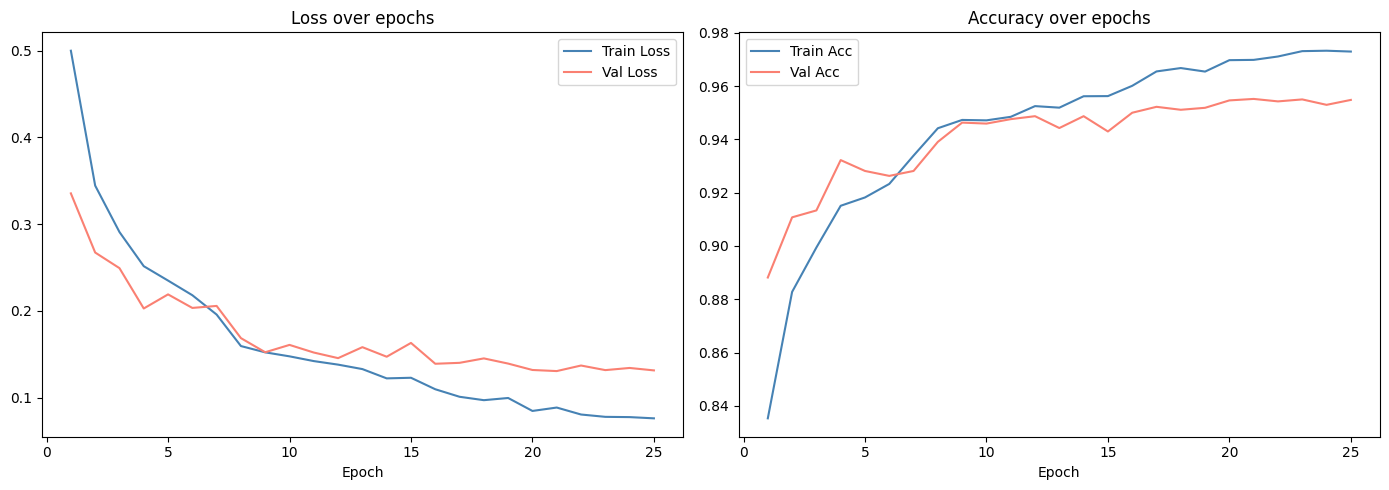

In [17]:
epochs = range(1, len(history_finetune["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history_finetune["train_loss"], label="Train Loss", color="steelblue")
axes[0].plot(epochs, history_finetune["val_loss"], label="Val Loss", color="salmon")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history_finetune["train_acc"], label="Train Acc", color="steelblue")
axes[1].plot(epochs, history_finetune["val_acc"], label="Val Acc", color="salmon")
axes[1].set_title("Accuracy over epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

The model's training process became less efficient after 12 epochs, which can be seen in the graph. Lower marginal increase in validation accuracy and decrease in validation loss were accompanied by relatively stable improvement in training accuracy and loss, which could potentially lead to overfitting, which is why the early stopping was triggered.

In [18]:
resnet.load_state_dict(torch.load("best_resnet_finetuned.pth"))
test_loss, test_acc = validate(resnet, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

100%|██████████| 85/85 [00:02<00:00, 30.73it/s]

Test Loss: 0.1151 | Test Accuracy: 0.9615


Test accuracy and loss are similar to scores during validation, which further proves that overfitting has been avoided.

                      precision    recall  f1-score   support

          AnnualCrop       0.97      0.98      0.97       300
              Forest       0.97      0.99      0.98       300
HerbaceousVegetation       0.95      0.95      0.95       300
             Highway       0.92      0.90      0.91       250
          Industrial       0.97      0.98      0.97       250
             Pasture       0.94      0.95      0.94       200
       PermanentCrop       0.95      0.92      0.93       250
         Residential       0.99      0.99      0.99       300
               River       0.93      0.95      0.94       250
             SeaLake       1.00      0.99      0.99       300

            accuracy                           0.96      2700
           macro avg       0.96      0.96      0.96      2700
        weighted avg       0.96      0.96      0.96      2700



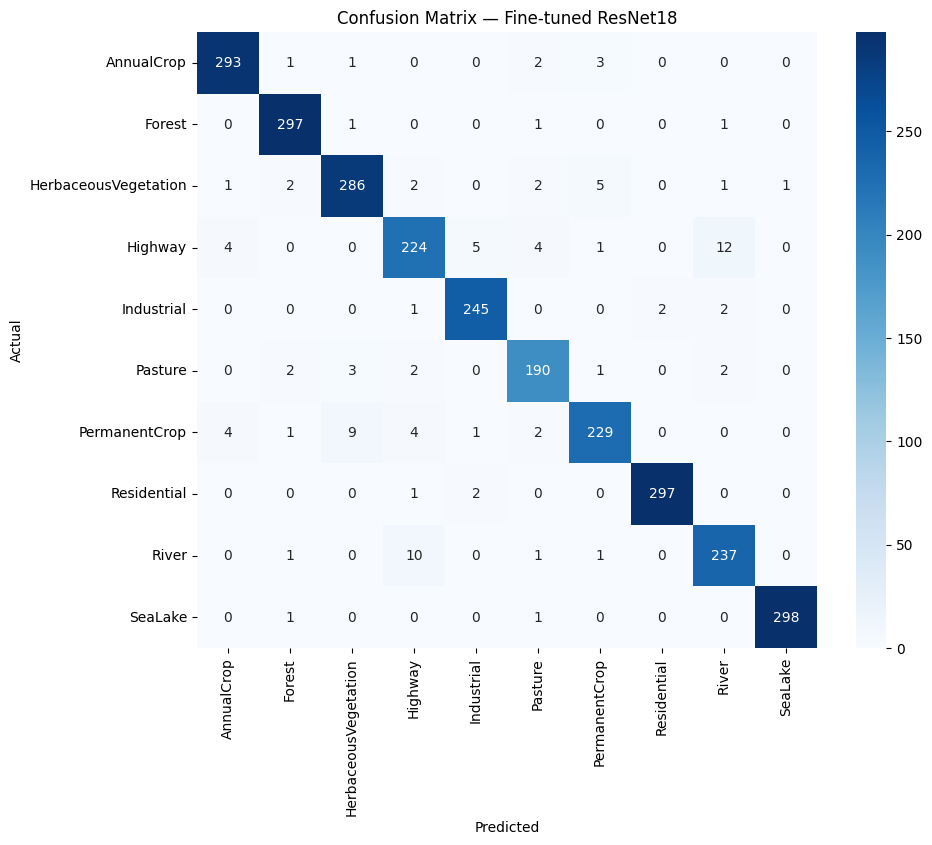

In [19]:
resnet.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = resnet(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

idx_to_class = {v: k for k, v in label_map.items()}
class_names = [idx_to_class[i] for i in range(10)]

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Fine-tuned ResNet18")
plt.show()

The fine-tuned ResNet18 demonstrated good performance on the EuroSAT classification task, achieving an overall accuracy of **0.96** on the test set. The model also obtained macro and weighted F1-scores of **0.96**, indicating strong and well-balanced performance across all ten classes.

The classification report indicates consistently high precision and recall for every class, with F1-scores ranging from **0.91** to **0.99**. The highest performance was achieved for ***Residential*** and ***SeaLake***, both with an F1-score of **0.99**, followed closely by ***Forest***, ***AnnualCrop***, and ***Industrial***. These classes contain distinctive visual patterns that make them easier for the model to identify. The remaining classes, including ***HerbaceousVegetation***, ***Highway***, ***Pasture***, ***PermanentCrop***, and ***River***, also achieved strong results, demonstrating the model's ability to accurately classify a wide range of land cover types.

The confusion matrix further highlights the model's effectiveness. The remaining misclassifications mainly occur between visually similar classes. For example, ***Highway*** is occasionally confused with ***River***, while ***PermanentCrop*** is sometimes misclassified as ***HerbaceousVegetation***. Such errors are expected, as these land cover categories often exhibit similar textures, colors, and spatial structures in satellite imagery.

Overall, the fine-tuned ResNet18 learned robust feature representations and generalized well to unseen data. The combination of high accuracy, balanced class-wise performance, and relatively few classification errors demonstrates that the model is highly effective for satellite image classification.

**Compared with the Baseline CNN, the fine-tuned ResNet18 achieved similar overall performance**, with both models reaching **0.96** accuracy and **0.96** macro and weighted F1-scores. While the distribution of classification errors differs slightly between the two models, the results suggest that **fine-tuning a pretrained ResNet18 did not provide a significant improvement over the Baseline CNN** on the EuroSAT dataset.